# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [1]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [2]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [3]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [4]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)

In [5]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [6]:
phase3_features = get_phase3_features()

In [7]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [8]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [9]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.4683
      Test MAE: 4.71 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.4006
      Test MAE: 13.00 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  -0.2544
      Test MAE: 26.07 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.9681
      Test MAE: 5.31 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.7499
      Test MAE: 41.08 HP

All 5 models trained successfully!


In [10]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    coef_df = pd.DataFrame({
        'feature': phase3_features,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
                 feature  coefficient
  speed_ground_deviation     2.187488
condition_immunity_count     1.890897
        has_spellcasting    -1.803668
     speed_fly_deviation     1.782674
       spellcaster_level     1.595835
      inflicts_petrified    -1.426951
      inflicts_paralyzed    -0.981334
        inflicts_blinded    -0.958432
             speed_climb    -0.916849
  save_proficiency_count     0.808207

CR2 Top Features by Coefficient:
                 feature  coefficient
  save_proficiency_count     7.968778
     inflicts_frightened    -5.440560
     vulnerability_count     4.808210
condition_immunity_count    -4.670084
              speed_swim     4.386655
        inflicts_charmed    -4.325434
 skill_proficiency_count    -4.244846
             speed_climb    -3.755308
  speed_ground_deviation     3.576846
             trait_count     3.136640

CR3 Top Features by Coefficient:
               feature  coefficient
      has_spellcasting   -

## Investigate Specific Creatures

In [11]:
# df[df['Name'].str.contains('Dragon')].head()

In [30]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
# Oni, Unicorn way too penalized for different reasons.
investigate_creature('Ape', df, contributions_df)

  APE (CR 0.5)

Actual HP:              19
Predicted HP:           24
Error:                   5  (  25.6%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 0.5):                                33

PHASE 2: COMBAT STATS
  Feature: ac_deviation                   value:    0.0  hp impact:     -0
  Feature: attack_deviation               value:    1.0  hp impact:     -2
  Feature: dpr_deviation                  value:    5.0  hp impact:     -4
  Feature: save_dc_deviation              value:    0.0  hp impact:     -0
  Feature: has_flying                     value:    0.0  hp impact:     -0
  Feature: has_advantage_condition        value:    0.0  hp impact:     -0
  Feature: has_disadvantage_condition     value:    0.0  hp impact:      0
  Feature: has_attackers_advantage        value:    0.0  hp impact:      0
  Feature: inflicts_prone                 value:    0.0  hp impact:     -0
  ------------------------------

In [28]:
[c for c in contributions_df.columns if 'feature' in c]

['feature_hp', 'feature_dpr', 'feature_ac', 'feature_attack']

In [15]:
# _df = analysis_dfs['cr3']
# _df.sort_values('predicted_hp')

In [16]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [17]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
      Name    CR  Actual_HP  Predicted_HP     Error
   Cultist 0.125          9      9.000022 -0.000022
Cockatrice 0.500         27     27.000022 -0.000022
      Pony 0.125         11     10.963348  0.036652
     Camel 0.125         15     15.113866 -0.113866
     Raven 0.000          1      0.819650  0.180350
  Scorpion 0.000          1      0.763503  0.236497
      Worg 0.500         26     25.707976  0.292024
      Wolf 0.250         11     10.651568  0.348432
  Shrieker 0.000         13     13.374611 -0.374611
  Axe Beak 0.250         19     18.613866  0.386134

CR < 1 - Worst 10 Predictions:
                 Name   CR  Actual_HP  Predicted_HP      Error
              Quipper 0.00          1     -9.386754  10.386754
Giant Poisonous Snake 0.25         11      0.071660  10.928340
    Constrictor Snake 0.25         13      2.069902  10.930098
                 Drow 0.25         13      1.879294  11.120706
               Dretch 0.25         18      6.74526

In [18]:
# analysis_dfs['cr2']['actual_hp'].value_counts()

In [19]:
_df_check = analysis_dfs['cr2']
_df_check[_df_check['actual_hp'] == 45]


,Name,cr_numeric,actual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile,hp_baseline,ac_baseline,attack_baseline,...,inflicts_prone,speed_ground_deviation,speed_fly_deviation,has_grapple,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
57,Rhinoceros,2.0,45,47.478751,2.478751,5.508337,14.141414,54.0,13.0,5.0,...,1,10.0,0,0,45,47.478751,2.0,-2.478751,2.478751,-5.508337
50,Hunter Shark,2.0,45,47.643192,2.643192,5.873760,16.161616,54.0,13.0,5.0,...,0,-30.0,0,0,45,47.643192,2.0,-2.643192,2.643192,-5.873760
66,Hell Hound,3.0,45,39.796837,-5.203163,-11.562584,27.272727,78.0,13.0,5.0,...,0,20.0,0,0,45,39.796837,3.0,5.203163,5.203163,11.562584
13,Giant Hyena,1.0,45,51.790532,6.790532,15.090072,31.313131,49.5,12.0,5.0,...,0,20.0,0,0,45,51.790532,1.0,-6.790532,6.790532,-15.090072
52,Merrow,2.0,45,53.559534,8.559534,19.021187,42.424242,54.0,13.0,5.0,...,0,-20.0,0,0,45,53.559534,2.0,-8.559534,8.559534,-19.021187
74,Wight,3.0,45,33.863560,-11.136440,-24.747644,50.505051,78.0,13.0,5.0,...,0,0.0,0,0,45,33.863560,3.0,11.136440,11.136440,24.747644
41,Centaur,2.0,45,29.621795,-15.378205,-34.173789,70.707071,54.0,13.0,5.0,...,0,20.0,0,0,45,29.621795,2.0,15.378205,15.378205,34.173789
39,Silver Dragon Wyrmling,2.0,45,27.969760,-17.030240,-37.844977,75.757576,54.0,13.0,5.0,...,0,0.0,20,0,45,27.969760,2.0,17.030240,17.030240,37.844977
47,Ochre Jelly,2.0,45,26.667608,-18.332392,-40.738650,77.777778,54.0,13.0,5.0,...,0,-20.0,0,0,45,26.667608,2.0,18.332392,18.332392,40.738650
87,Ghost,4.0,45,89.488804,44.488804,98.864009,93.939394,100.8,14.0,6.0,...,0,-30.0,0,0,45,89.488804,4.0,-44.488804,44.488804,-98.864009


In [24]:
[c for c in _df_check.columns if 'save' in c]

['highest_save_dc', 'save_dc_deviation', 'save_proficiency_count']


📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


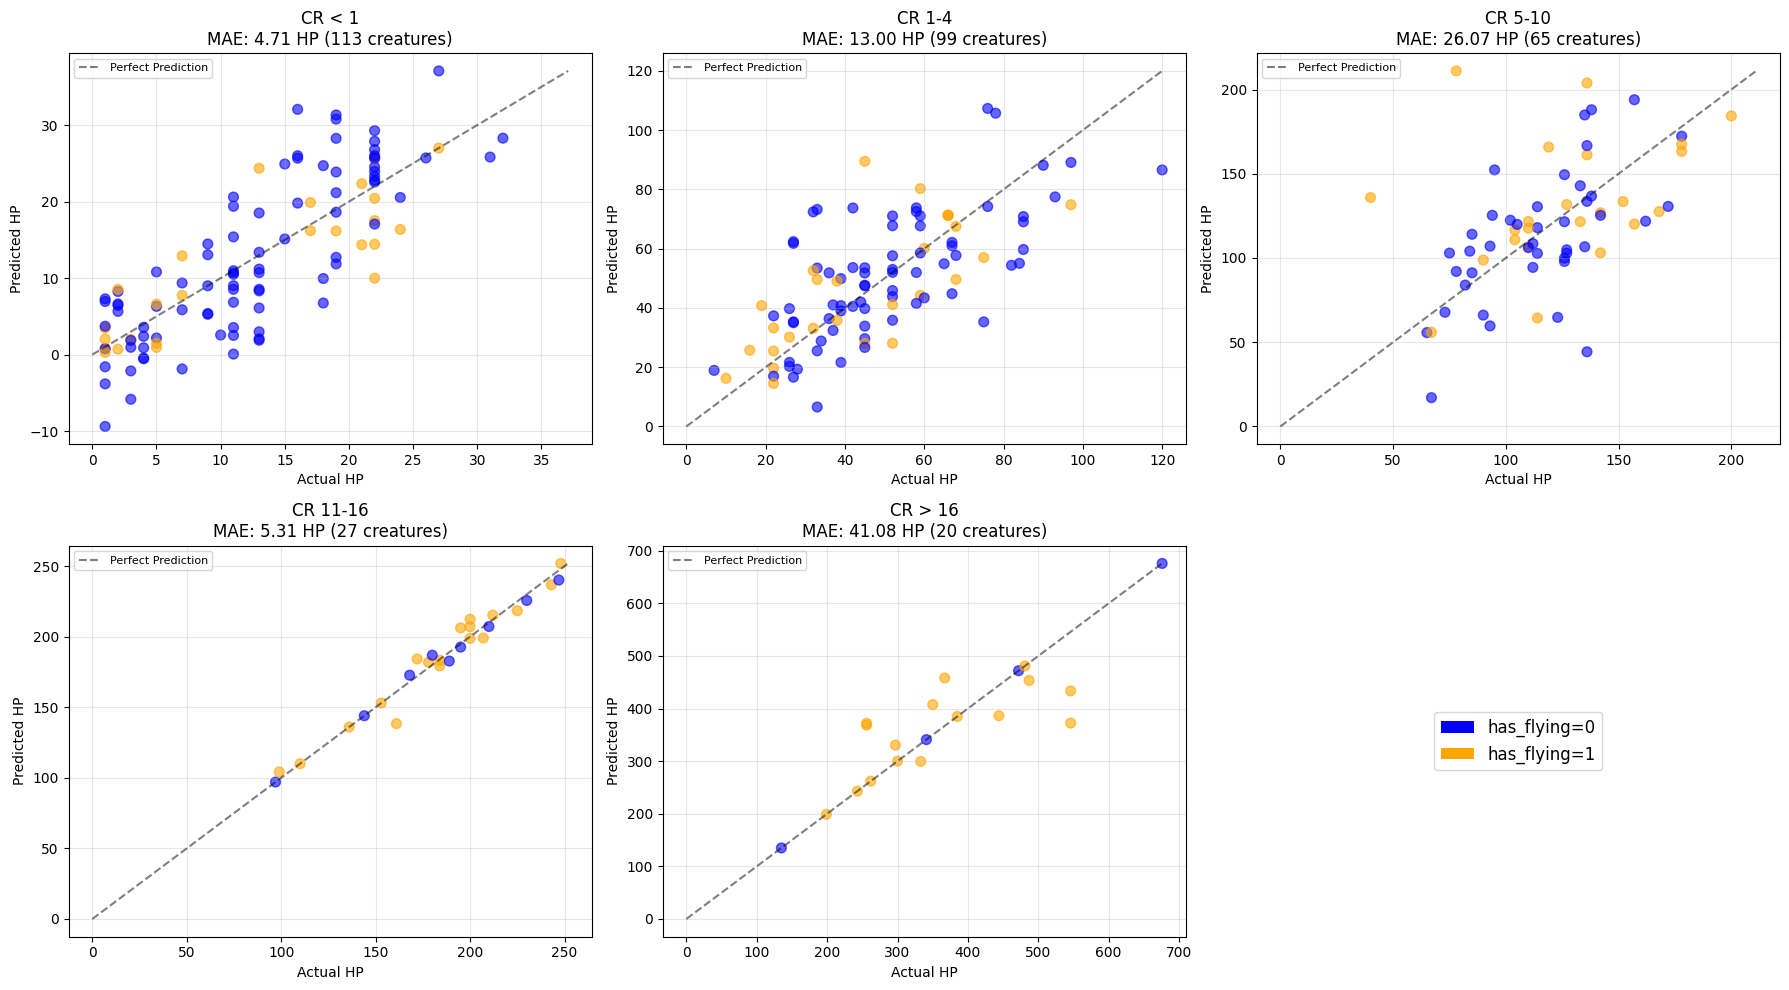

In [31]:
plot_performance_scatter(analysis_dfs, highlight_feature='has_flying')

In [34]:
_df = analysis_dfs['cr3']
_df.sort_values('predicted_hp')

,Name,cr_numeric,actual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile,hp_baseline,ac_baseline,attack_baseline,...,inflicts_prone,speed_ground_deviation,speed_fly_deviation,has_grapple,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
23,Unicorn,5.0,67,17.086798,-49.913202,-74.497316,96.923077,114.0,15.0,7.0,...,1,20.0,0,0,67,17.086798,5.0,49.913202,49.913202,74.497316
9,Shambling Mound,5.0,136,44.320355,-91.679645,-67.411504,95.384615,114.0,15.0,7.0,...,0,-10.0,0,1,136,44.320355,5.0,91.679645,91.679645,67.411504
1,Half-Red Dragon Veteran,5.0,65,55.713893,-9.286107,-14.286319,43.076923,114.0,15.0,7.0,...,0,0.0,0,0,65,55.713893,5.0,9.286107,9.286107,14.286319
12,Wraith,5.0,67,55.881713,-11.118287,-16.594459,49.230769,114.0,15.0,7.0,...,0,-30.0,0,0,67,55.881713,5.0,11.118287,11.118287,16.594459
5,Roper,5.0,93,59.684150,-33.315850,-35.823495,81.538462,114.0,15.0,7.0,...,0,-20.0,0,1,93,59.684150,5.0,33.315850,33.315850,35.823495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,Aboleth,10.0,135,184.912193,49.912193,36.971995,84.615385,186.0,17.0,9.0,...,0,-20.0,0,0,135,184.912193,10.0,-49.912193,49.912193,-36.971995
55,Treant,9.0,138,188.013916,50.013916,36.241968,83.076923,174.0,16.0,8.0,...,0,0.0,0,0,138,188.013916,9.0,-50.013916,50.013916,-36.241968
39,Giant Ape,7.0,157,193.944597,36.944597,23.531591,67.692308,156.0,15.0,7.0,...,0,10.0,0,0,157,193.944597,7.0,-36.944597,36.944597,-23.531591
60,Deva,10.0,136,203.907288,67.907288,49.931829,92.307692,186.0,17.0,9.0,...,0,0.0,30,0,136,203.907288,10.0,-67.907288,67.907288,-49.931829



📊 VISUALIZATION: Error Distribution (5 CR Buckets)


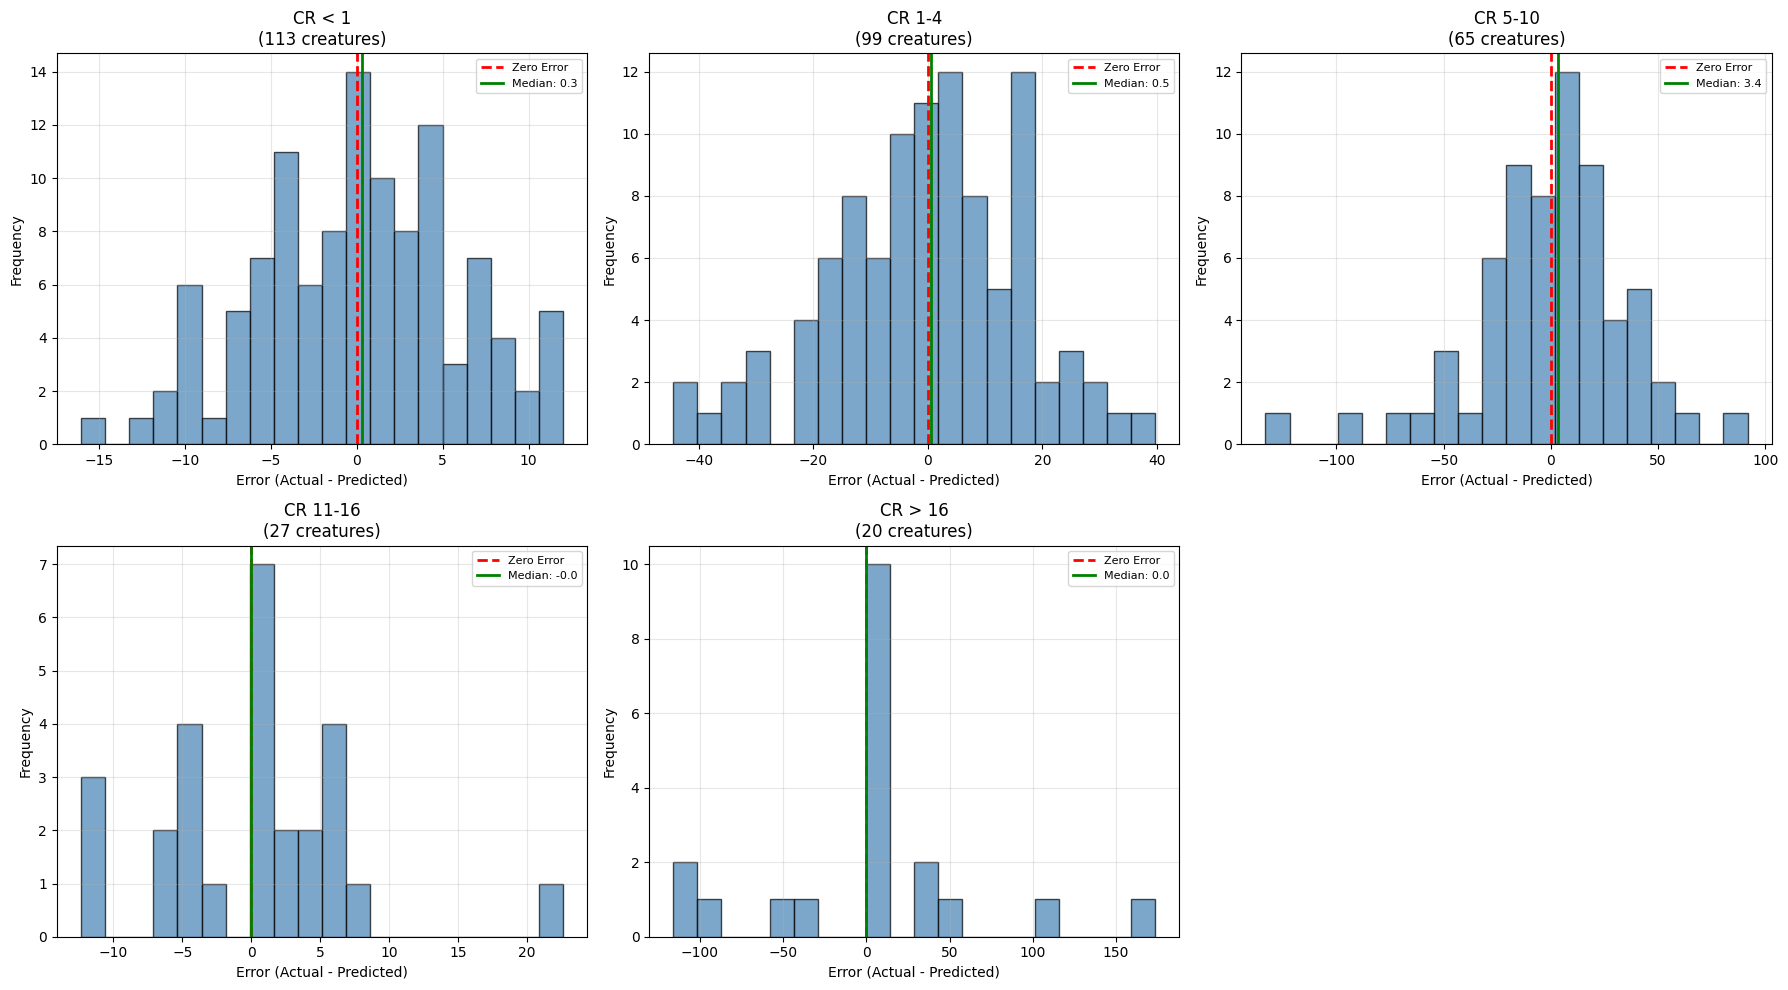

In [33]:
plot_error_hist(analysis_dfs)